#Importing the dependencies


In [76]:
import os

# Create a directory to save the figures if it doesn't exist
if not os.path.exists('figures'):
    os.makedirs('figures')
print("Created 'figures' directory.")

Created 'figures' directory.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

#Data collection and Analysis


In [3]:
#loading dataset from csv file to pandas DataFrame
big_mart_data = pd.read_csv('/content/big_mart_sales_data.csv')

In [4]:
#first 5 rows of the dataframe
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [5]:
#number of data points and number of features
big_mart_data.shape

(5681, 11)

In [6]:
#getting some information about this dataset
big_mart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


Categorical features:

-Item_identifier

-Item_fat_content

-item_type

-outlet_identifier

-outlet_size

-outlet_location_type

-outlet_type


In [7]:
#checking for missing values
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,976
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1606
Outlet_Location_Type,0


Hnadling Missing Values

Mean --> average value

mode --> most repeated value

In [8]:
#mean value of item_weight column
big_mart_data['Item_Weight'].mean()

np.float64(12.695633368756642)

In [9]:
#filling the missing value of item_weight column with mean value
big_mart_data['Item_Weight'].fillna(big_mart_data['Item_Weight'].mean(), inplace=True)


/tmp/ipykernel_10008/2446644413.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  big_mart_data['Item_Weight'].fillna(big_mart_data['Item_Weight'].mean(), inplace=True)


In [10]:
 #checking for missing values
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1606
Outlet_Location_Type,0


REplacing missing values in outlet_size iwth mode

In [11]:
mode_of_outlet_size = big_mart_data.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x:x.mode()[0]))
print(mode_of_outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2 Supermarket Type3
Outlet_Size         Small             Small            Medium            Medium


In [12]:
missing_values = big_mart_data['Outlet_Size'].isnull()
print(missing_values)

0       False
1        True
2        True
3        True
4       False
        ...  
5676    False
5677    False
5678     True
5679     True
5680     True
Name: Outlet_Size, Length: 5681, dtype: bool


In [13]:
big_mart_data.loc[missing_values, 'Outlet_Size'] = big_mart_data.loc[missing_values, 'Outlet_Type'].apply(lambda x: mode_of_outlet_size[x])

In [14]:
 #checking for missing values
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


#Data Analysis

In [15]:
#statistical measure about the data
big_mart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,5681.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.245189,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,9.195000,0.027047,94.412000,1987.000000
50%,12.695633,0.054154,141.415400,1999.000000
75%,15.850000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


Numerical features

In [16]:
sns.set()

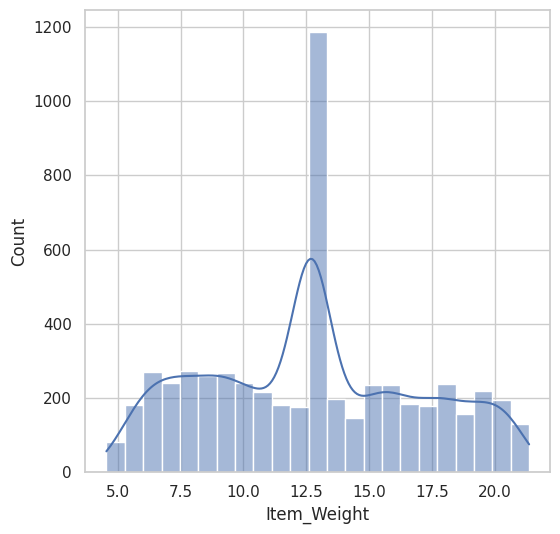

In [95]:
#item_weight distribution
plt.figure(figsize=(6,6))
sns.histplot(big_mart_data['Item_Weight'], kde=True)
plt.savefig('figures/item_weight_distribution.png', transparent=True)
plt.show()

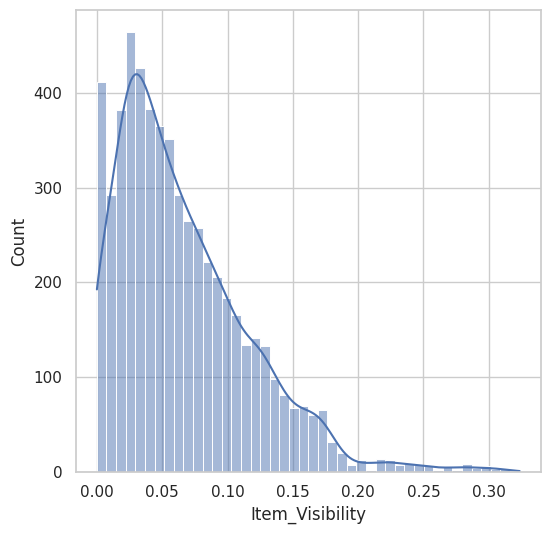

In [96]:
#item_visibility_distribution
plt.figure(figsize=(6,6))
sns.histplot(big_mart_data['Item_Visibility'], kde=True)
plt.savefig('figures/item_visibility_distribution.png', transparent=True)
plt.show()

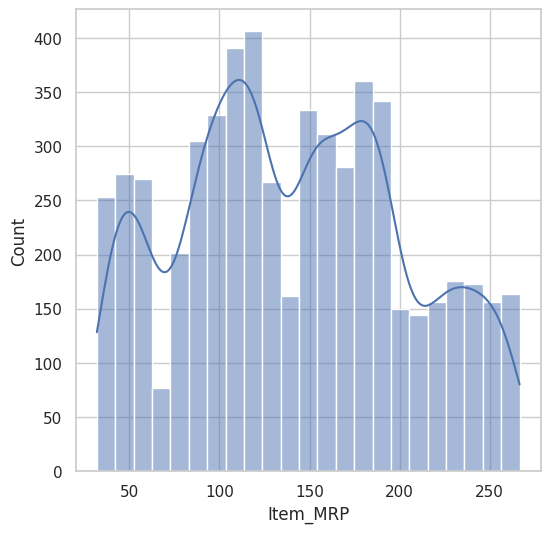

In [97]:
#Item_MRP_distribution
plt.figure(figsize=(6,6))
sns.histplot(big_mart_data['Item_MRP'], kde=True)
plt.savefig('figures/item_mrp_distribution.png', transparent=True)
plt.show()

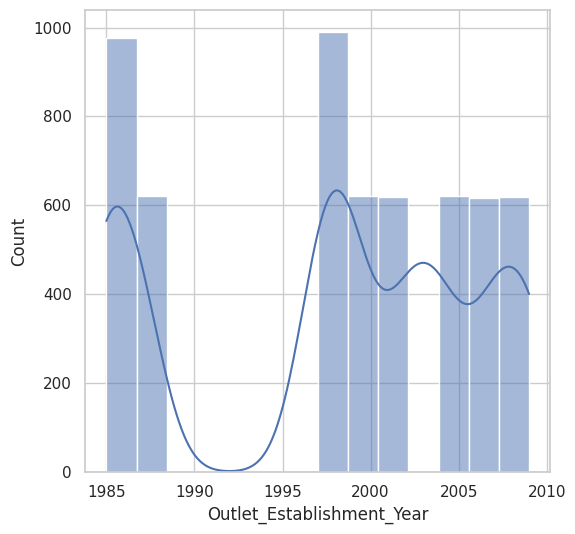

In [98]:
#Outlet_Establishment_Year_distribution
plt.figure(figsize=(6,6))
sns.histplot(big_mart_data['Outlet_Establishment_Year'], kde=True)
plt.savefig('figures/outlet_establishment_year_distplot.png', transparent=True)
plt.show()

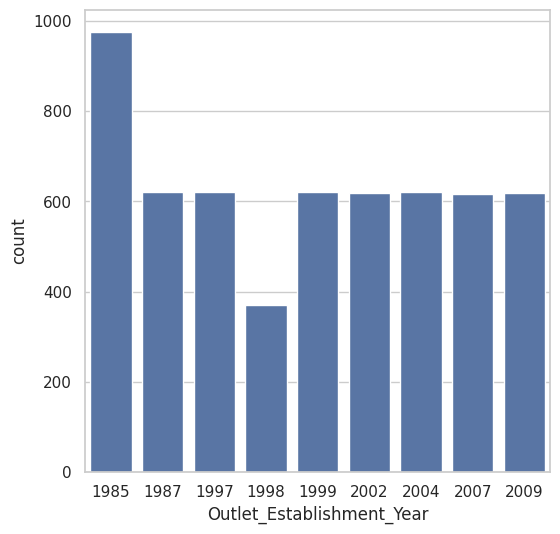

In [81]:
#Outlet_Establishment_Year
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year', data=big_mart_data)
plt.savefig('figures/outlet_establishment_year_countplot.png', transparent=True)
plt.show()

Categorical features

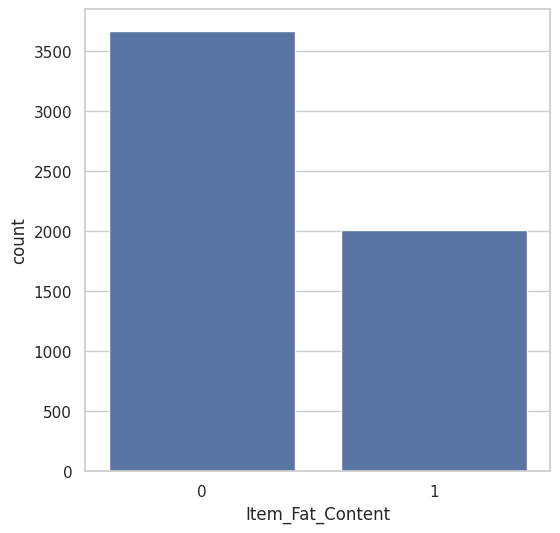

In [82]:
#Item_Fat_Content
plt.figure(figsize=(6,6))
sns.countplot(x='Item_Fat_Content', data=big_mart_data)
plt.savefig('figures/item_fat_content_countplot.png', transparent=True)
plt.show()

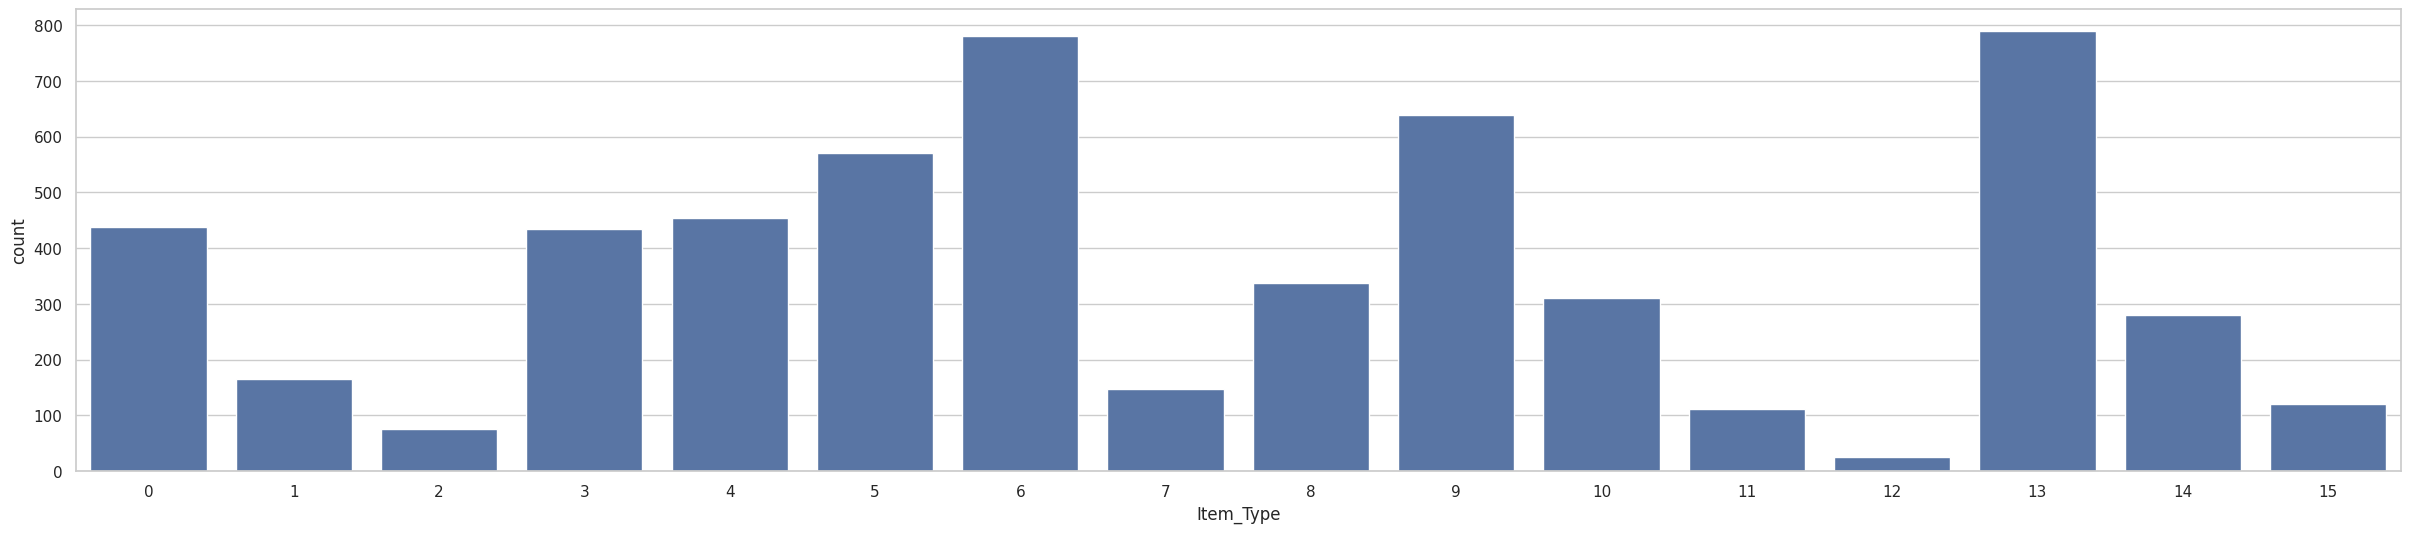

In [83]:
#Item_Type
plt.figure(figsize=(30,6))
sns.countplot(x='Item_Type', data=big_mart_data)
plt.savefig('figures/item_type_countplot.png', transparent=True)
plt.show()

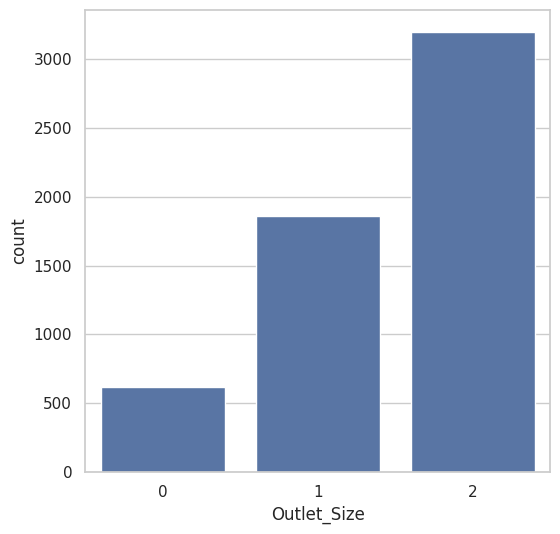

In [84]:
#Outlet_Size
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Size', data=big_mart_data)
plt.savefig('figures/outlet_size_countplot.png', transparent=True)
plt.show()

#Data Preprocessing

In [29]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750000,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300000,reg,0.038428,Dairy,87.3198,OUT017,2007,Small,Tier 2,Supermarket Type1
2,NCN55,14.600000,Low Fat,0.099575,Others,241.7538,OUT010,1998,Small,Tier 3,Grocery Store
3,FDQ58,7.315000,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Small,Tier 2,Supermarket Type1
4,FDY38,12.695633,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [30]:
big_mart_data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3396
Regular,1935
LF,206
reg,78
low fat,66


In [31]:
big_mart_data.replace({'Item_Fat_Content': {'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'}}, inplace=True)

In [32]:
big_mart_data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3668
Regular,2013


Label Encoding

In [33]:
encoder = LabelEncoder()

In [36]:
big_mart_data['Item_Identifier'] = encoder.fit_transform(big_mart_data['Item_Identifier'])
big_mart_data['Item_Fat_Content'] = encoder.fit_transform(big_mart_data['Item_Fat_Content'])
big_mart_data['Item_Type'] = encoder.fit_transform(big_mart_data['Item_Type'])
big_mart_data['Outlet_Identifier'] = encoder.fit_transform(big_mart_data['Outlet_Identifier'])
big_mart_data['Outlet_Size'] = encoder.fit_transform(big_mart_data['Outlet_Size'])
big_mart_data['Outlet_Location_Type'] = encoder.fit_transform(big_mart_data['Outlet_Location_Type'])
big_mart_data['Outlet_Type'] = encoder.fit_transform(big_mart_data['Outlet_Type'])

In [37]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,1103,20.750000,0,0.007565,13,107.8622,9,1999,1,0,1
1,1067,8.300000,1,0.038428,4,87.3198,2,2007,2,1,1
2,1406,14.600000,0,0.099575,11,241.7538,0,1998,2,2,0
3,809,7.315000,0,0.015388,13,155.0340,2,2007,2,1,1
4,1184,12.695633,1,0.118599,4,234.2300,5,1985,1,2,3


Splittinng features and target

In [45]:
X = big_mart_data.drop(columns='Item_MRP', axis=1)
Y = big_mart_data['Item_MRP']

In [46]:
print(big_mart_data.columns)

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')


In [47]:
print(x)

      Item_Identifier  Item_Weight  ...  Outlet_Location_Type  Outlet_Type
0                1103    20.750000  ...                     0            1
1                1067     8.300000  ...                     1            1
2                1406    14.600000  ...                     2            0
3                 809     7.315000  ...                     1            1
4                1184    12.695633  ...                     2            3
...               ...          ...  ...                   ...          ...
5676              231    10.500000  ...                     0            1
5677              306     7.600000  ...                     2            2
5678             1412    10.000000  ...                     1            1
5679              517    15.300000  ...                     1            1
5680              987     9.500000  ...                     1            1

[5681 rows x 10 columns]


In [48]:
print(y)

0       107.8622
1        87.3198
2       241.7538
3       155.0340
4       234.2300
          ...   
5676    141.3154
5677    169.1448
5678    118.7440
5679    214.6218
5680     79.7960
Name: Item_MRP, Length: 5681, dtype: float64


Splitting the data into training data & testing data

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [51]:
print(X.shape, X_train.shape, X_test.shape)

(5681, 10) (4544, 10) (1137, 10)


#Machine Learning model training

In [52]:
regressor = XGBRegressor()

In [54]:
regressor.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#Evaluation

In [55]:
#prediction on training data
training_data_prediction = regressor.predict(X_train)

In [56]:
# R squared value
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print('R Squared value = ', r2_train)

R Squared value =  0.8912723375587464


In [57]:
#prediction on test data
test_data_prediction = regressor.predict(X_test)

In [59]:
# R squared value
r2_test = metrics.r2_score(Y_test, test_data_prediction)
print('R Squared value = ', r2_test)

R Squared value =  0.6091708018354202


### Visualizing Actual vs. Predicted Values

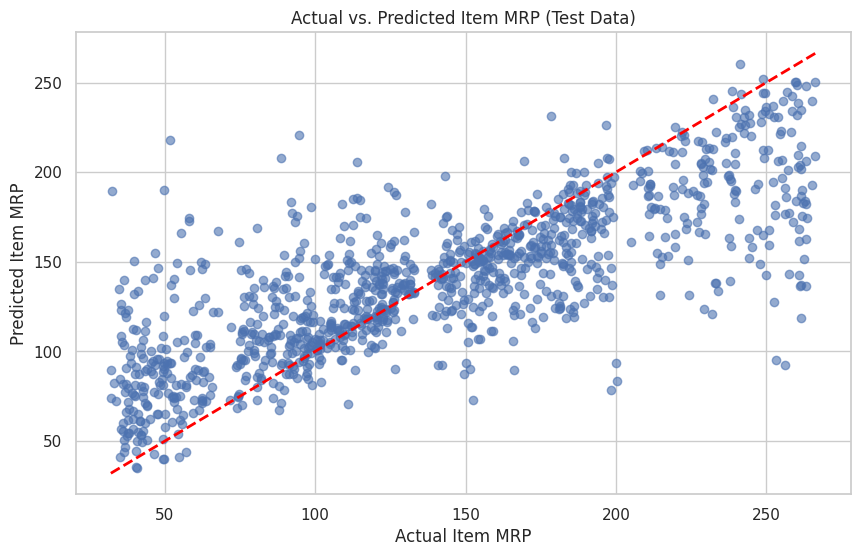

In [85]:
# Visualize the actual vs predicted values for the test data
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, test_data_prediction, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Item MRP')
plt.ylabel('Predicted Item MRP')
plt.title('Actual vs. Predicted Item MRP (Test Data)')
plt.grid(True)
plt.savefig('figures/actual_vs_predicted_initial_model.png', transparent=True)
plt.show()

### Feature Importance Analysis

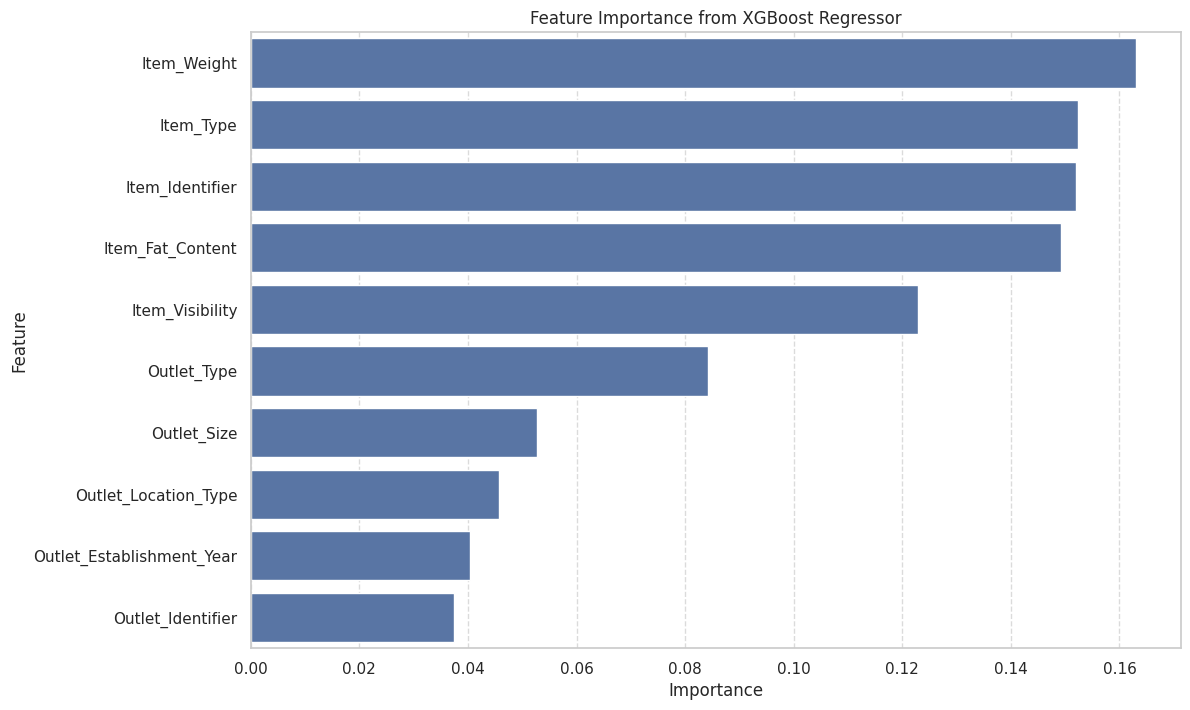

Top 10 Most Important Features:
                     Feature  Importance
1                Item_Weight    0.163136
4                  Item_Type    0.152294
0            Item_Identifier    0.151927
2           Item_Fat_Content    0.149215
3            Item_Visibility    0.122955
9                Outlet_Type    0.084291
7                Outlet_Size    0.052665
8       Outlet_Location_Type    0.045738
6  Outlet_Establishment_Year    0.040375
5          Outlet_Identifier    0.037406


In [86]:
# Get feature importances from the regressor
feature_importance = regressor.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importance from XGBoost Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('figures/feature_importance.png', transparent=True)
plt.show()

print("Top 10 Most Important Features:")
print(features_df.head(10))

### Hyperparameter Tuning

In [62]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=2, use_label_encoder=False, eval_metric='rmse'),
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2 # Show progress
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, Y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best R-squared score found: ", grid_search.best_score_)

# Get the best estimator
best_regressor = grid_search.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:37:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found:  {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}
Best R-squared score found:  0.5134104376432544


### Re-evaluating Model with Tuned Hyperparameters

In [63]:
# Make predictions on the test data using the best estimator
tuned_test_data_prediction = best_regressor.predict(X_test)

# Calculate the R squared value for the tuned model on test data
r2_test_tuned = metrics.r2_score(Y_test, tuned_test_data_prediction)
print('R Squared value (Tuned Model on Test Data) = ', r2_test_tuned)

# Also check training R-squared for the tuned model
tuned_training_data_prediction = best_regressor.predict(X_train)
r2_train_tuned = metrics.r2_score(Y_train, tuned_training_data_prediction)
print('R Squared value (Tuned Model on Training Data) = ', r2_train_tuned)

R Squared value (Tuned Model on Test Data) =  0.6709189234106037
R Squared value (Tuned Model on Training Data) =  0.9923990177199007


### Visualizing Actual vs. Predicted Values (Tuned Model)

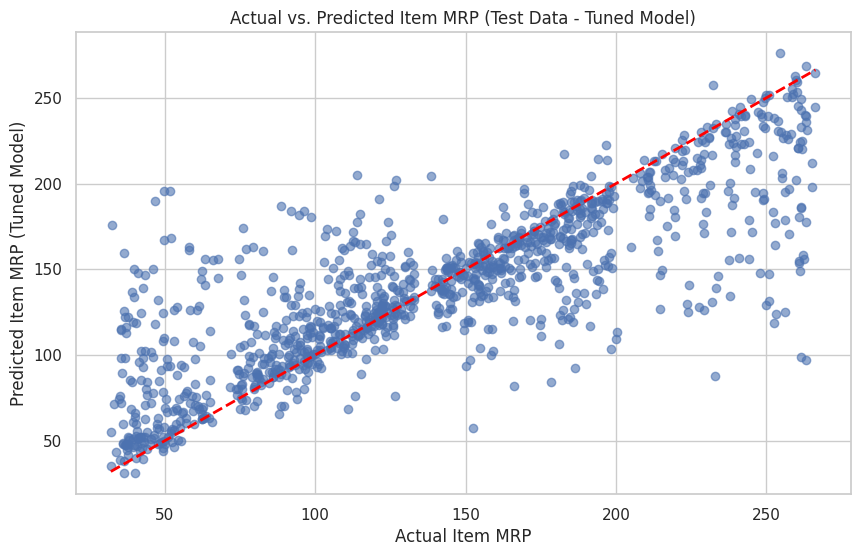

In [87]:
# Visualize the actual vs predicted values for the test data with the tuned model
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, tuned_test_data_prediction, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Item MRP')
plt.ylabel('Predicted Item MRP (Tuned Model)')
plt.title('Actual vs. Predicted Item MRP (Test Data - Tuned Model)')
plt.grid(True)
plt.savefig('figures/actual_vs_predicted_tuned_model.png', transparent=True)
plt.show()

### Cross-Validation for Tuned Model

Cross-validation helps us evaluate the model's performance more robustly by training and testing it on different subsets of the data. This provides a better understanding of how the model generalizes to unseen data and reduces the risk of results being specific to a particular train-test split.

In [65]:
from sklearn.model_selection import KFold, cross_val_score

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=2) # 5 folds, shuffled to ensure randomness

# Perform cross-validation using the best_regressor
# We'll use the full dataset X and Y to get a general idea of the model's performance on all data
cv_scores = cross_val_score(best_regressor, X, Y, cv=kf, scoring='r2', n_jobs=-1)

print("Cross-validation R-squared scores:", cv_scores)
print("Mean CV R-squared:", np.mean(cv_scores))
print("Standard deviation of CV R-squared:", np.std(cv_scores))

Cross-validation R-squared scores: [0.67091892 0.68306497 0.70106387 0.66027371 0.69082769]
Mean CV R-squared: 0.6812298331316351
Standard deviation of CV R-squared: 0.014382973367997426


The cross-validation R-squared scores provide a range of performance metrics, giving us a more stable estimate of the model's generalization capability. The mean R-squared indicates the average performance across different folds, while the standard deviation shows the variability of these scores. A higher mean and a lower standard deviation generally indicate a more robust and consistent model.

### Error Analysis

Error analysis helps us understand the types of errors our model is making and where it struggles. By examining the residuals (the difference between actual and predicted values), we can gain insights into potential biases, heteroscedasticity, or specific data points that are difficult for the model to predict.

In [66]:
# Calculate residuals for the tuned model on the test data
residuals = Y_test - tuned_test_data_prediction

print("Mean of residuals:", np.mean(residuals))
print("Standard deviation of residuals:", np.std(residuals))

Mean of residuals: -0.3273932032790645
Standard deviation of residuals: 36.62478669770321


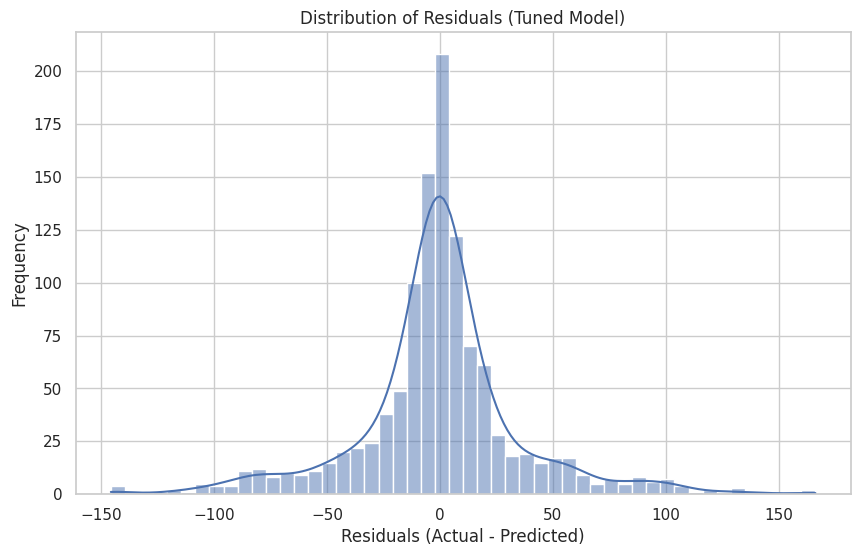

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Residuals (Tuned Model)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('figures/residuals_distribution.png', transparent=True)
plt.show()

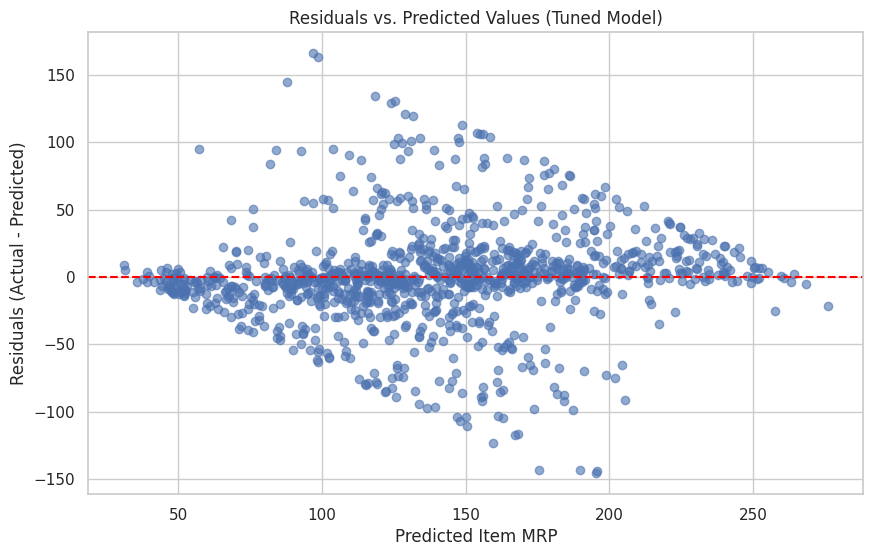

In [89]:
# Plot residuals vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(tuned_test_data_prediction, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Tuned Model)')
plt.xlabel('Predicted Item MRP')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.savefig('figures/residuals_vs_predicted.png', transparent=True)
plt.show()

These plots provide visual insights into the model's errors:

*   **Distribution of Residuals:** Ideally, residuals should be normally distributed around zero. Any skewness or unusual patterns might indicate bias or uncaptured information.
*   **Residuals vs. Predicted Values:** This plot helps identify heteroscedasticity (when the spread of residuals changes with the predicted value) or systematic patterns, which could mean the model struggles with certain ranges of predictions. A random scatter around zero is generally desired.

### Consolidated Visualizations

Here are all the key graphical representations from our analysis, presented for easier review and reporting.

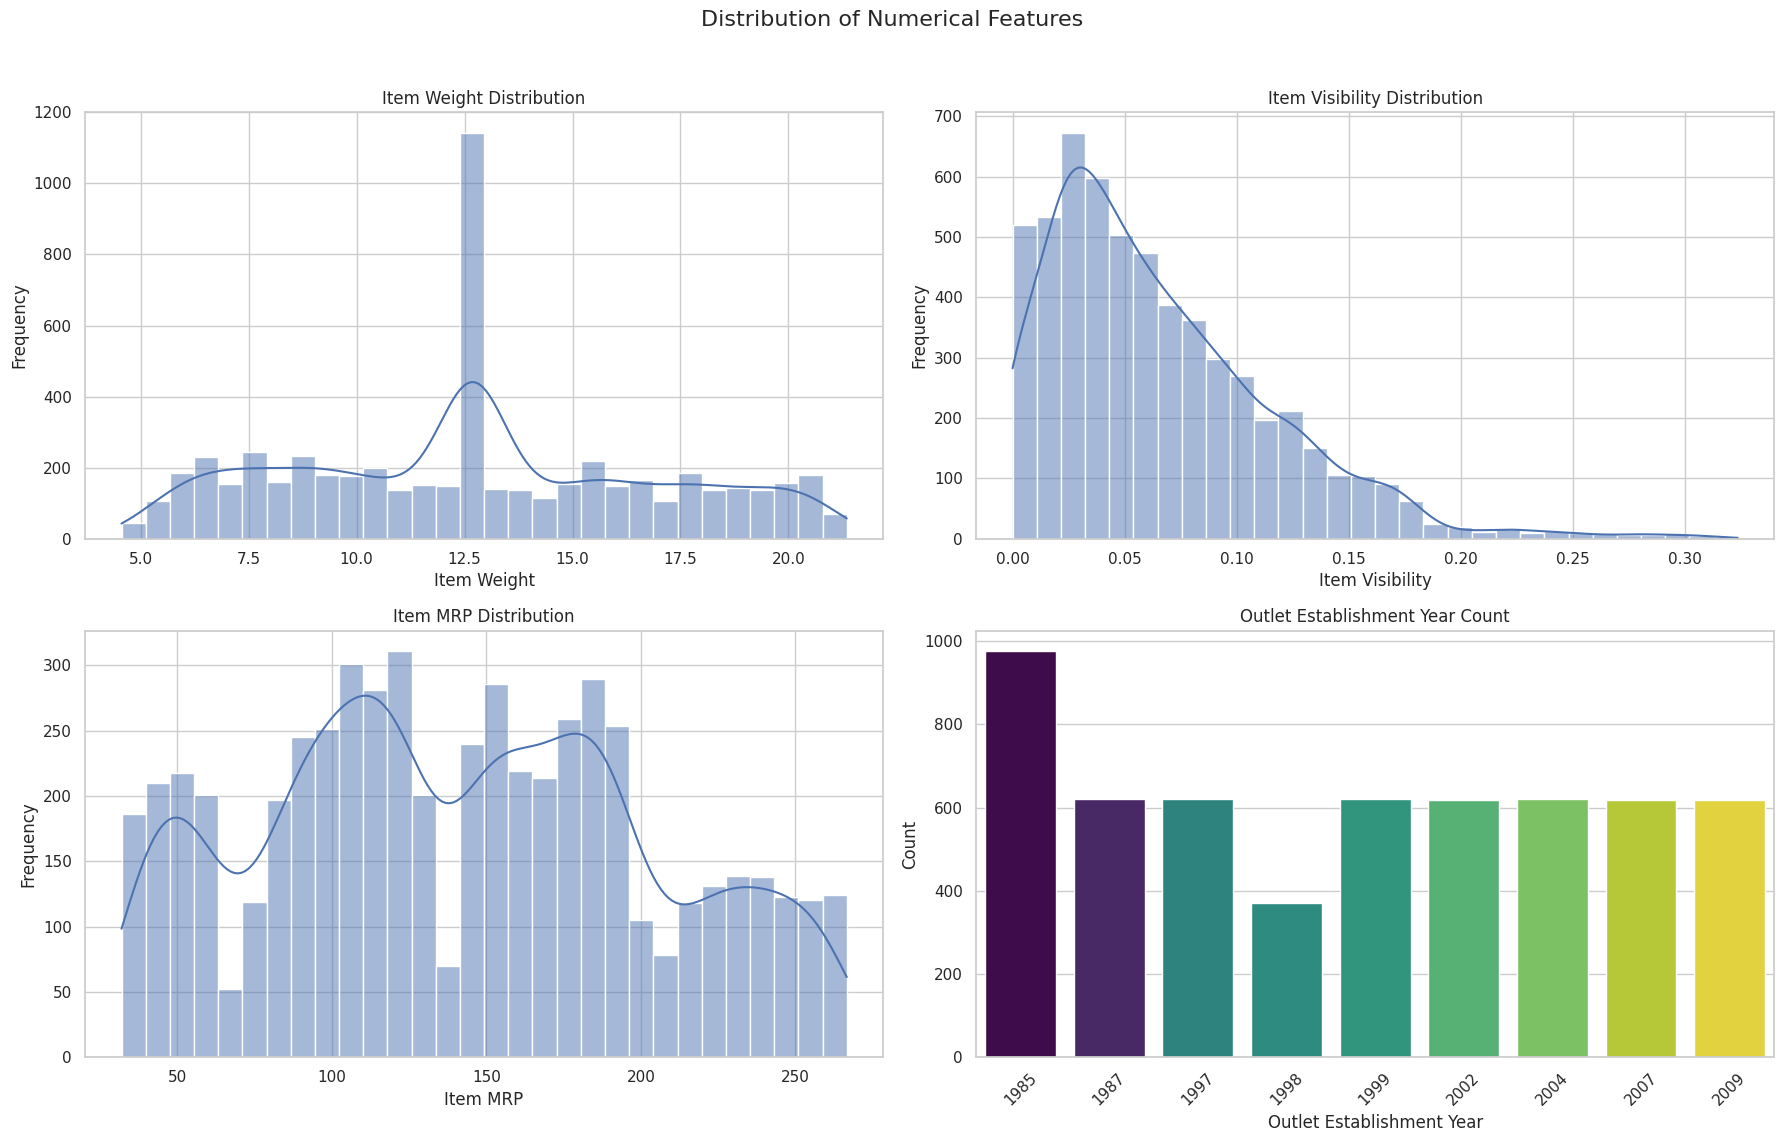

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set_style("whitegrid")

# Numerical Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16)

sns.histplot(big_mart_data['Item_Weight'], kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Item Weight Distribution')
axes[0, 0].set_xlabel('Item Weight')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(big_mart_data['Item_Visibility'], kde=True, bins=30, ax=axes[0, 1])
axes[0, 1].set_title('Item Visibility Distribution')
axes[0, 1].set_xlabel('Item Visibility')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(big_mart_data['Item_MRP'], kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Item MRP Distribution')
axes[1, 0].set_xlabel('Item MRP')
axes[1, 0].set_ylabel('Frequency')

sns.countplot(x='Outlet_Establishment_Year', data=big_mart_data, ax=axes[1, 1], hue='Outlet_Establishment_Year', palette='viridis', legend=False)
axes[1, 1].set_title('Outlet Establishment Year Count')
axes[1, 1].set_xlabel('Outlet Establishment Year')
axes[1, 1].set_ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('figures/consolidated_numerical_feature_distributions.png', transparent=True)
plt.show()

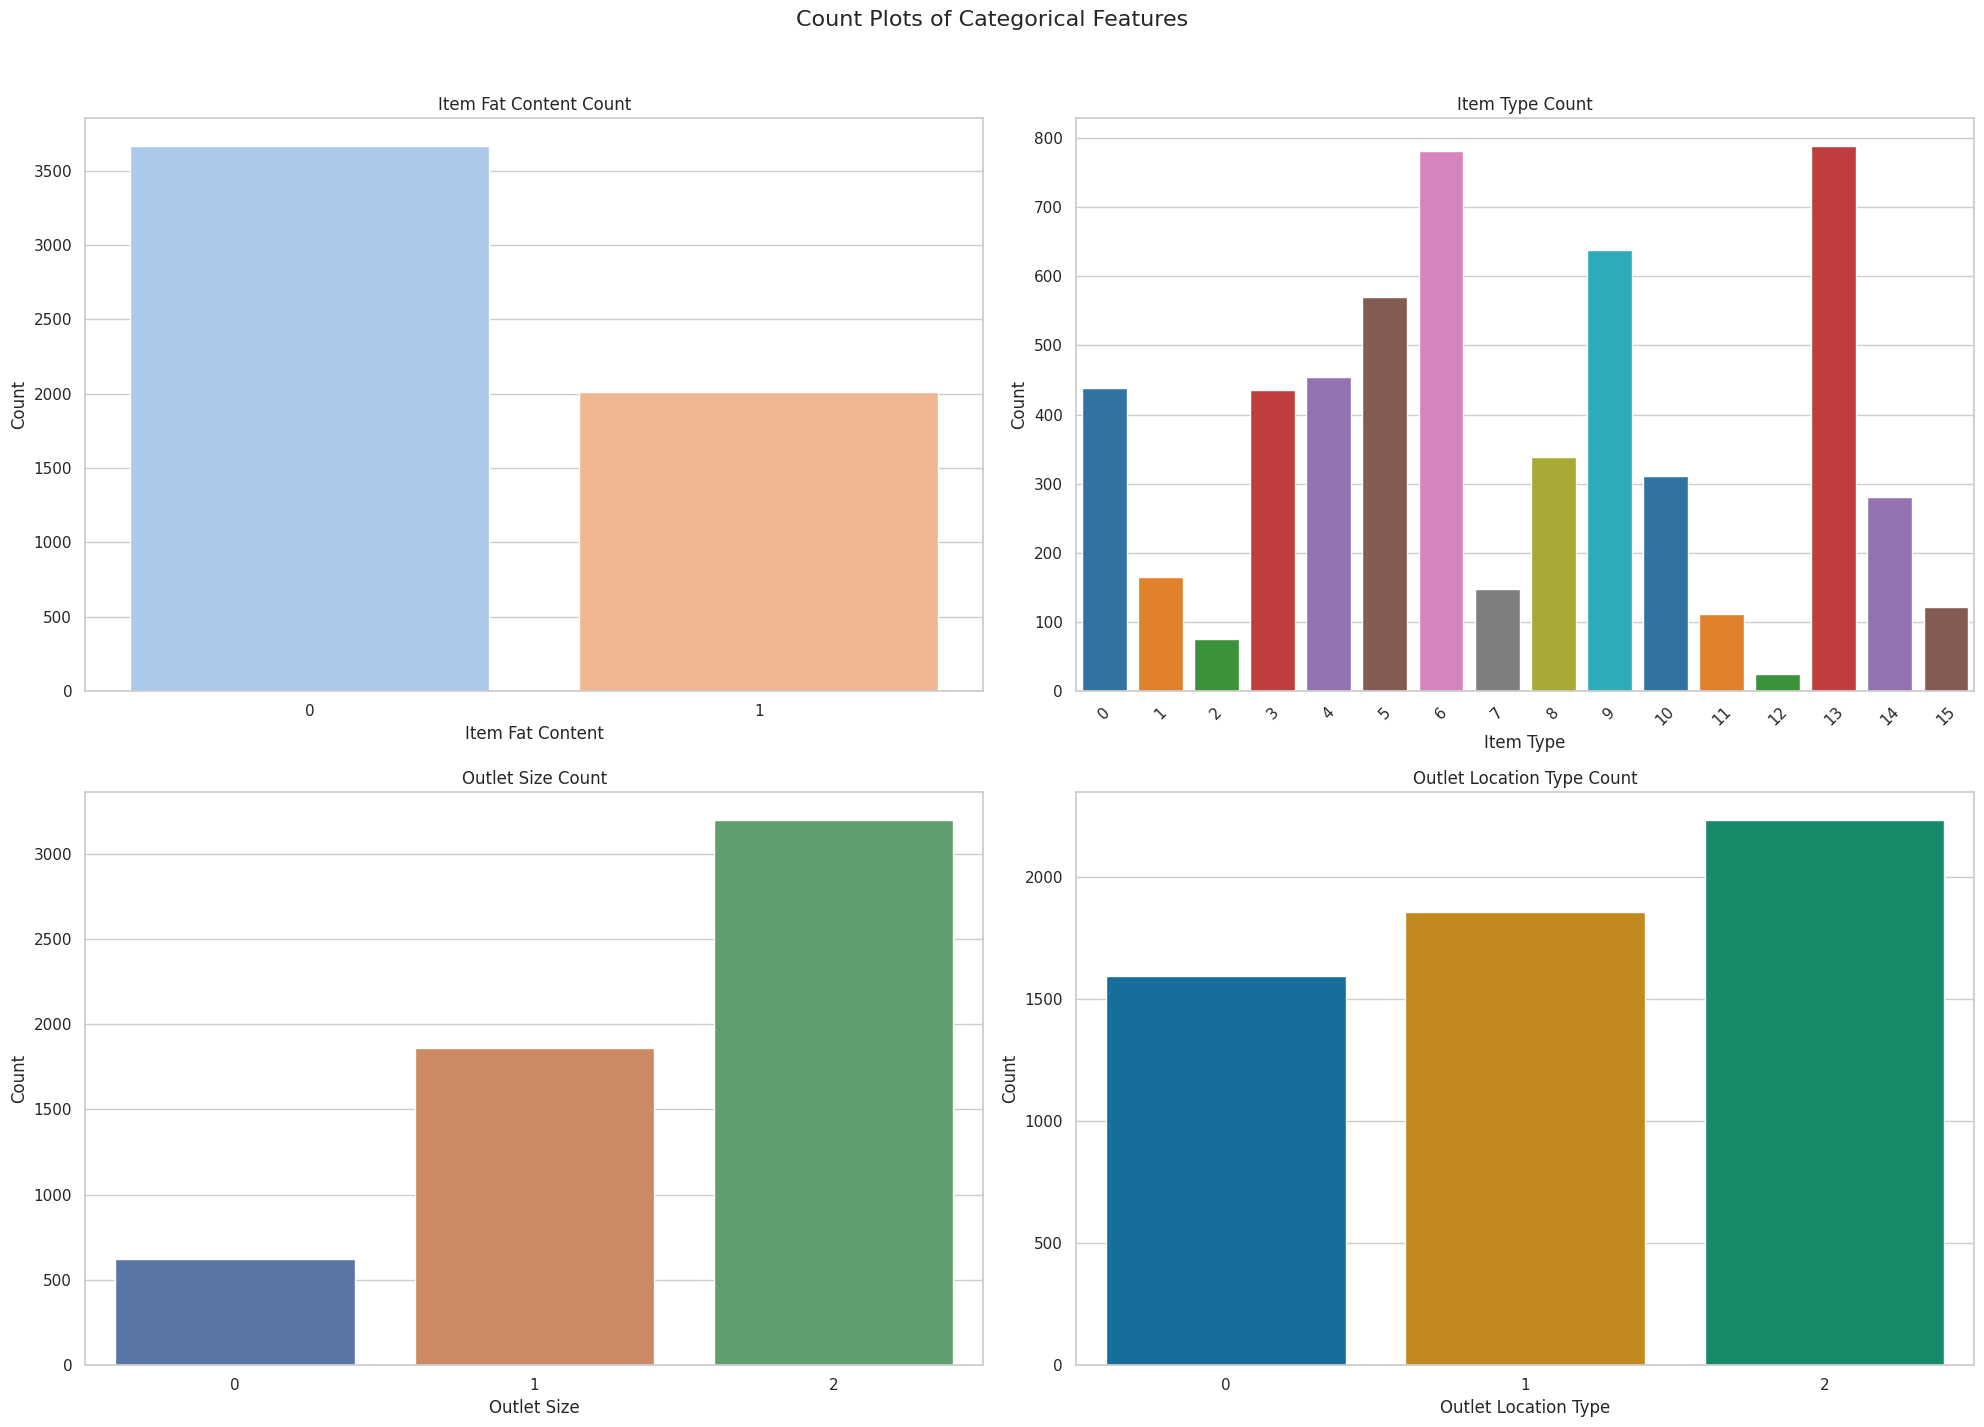

In [100]:
# Categorical Feature Count Plots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Count Plots of Categorical Features', fontsize=16)

sns.countplot(x='Item_Fat_Content', data=big_mart_data, ax=axes[0, 0], hue='Item_Fat_Content', palette='pastel', legend=False)
axes[0, 0].set_title('Item Fat Content Count')
axes[0, 0].set_xlabel('Item Fat Content')
axes[0, 0].set_ylabel('Count')

sns.countplot(x='Item_Type', data=big_mart_data, ax=axes[0, 1], hue='Item_Type', palette='tab10', legend=False)
axes[0, 1].set_title('Item Type Count')
axes[0, 1].set_xlabel('Item Type')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(x='Outlet_Size', data=big_mart_data, ax=axes[1, 0], hue='Outlet_Size', palette='deep', legend=False)
axes[1, 0].set_title('Outlet Size Count')
axes[1, 0].set_xlabel('Outlet Size')
axes[1, 0].set_ylabel('Count')

sns.countplot(x='Outlet_Location_Type', data=big_mart_data, ax=axes[1, 1], hue='Outlet_Location_Type', palette='colorblind', legend=False)
axes[1, 1].set_title('Outlet Location Type Count')
axes[1, 1].set_xlabel('Outlet Location Type')
axes[1, 1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('figures/consolidated_categorical_feature_count_plots.png', transparent=True)
plt.show()

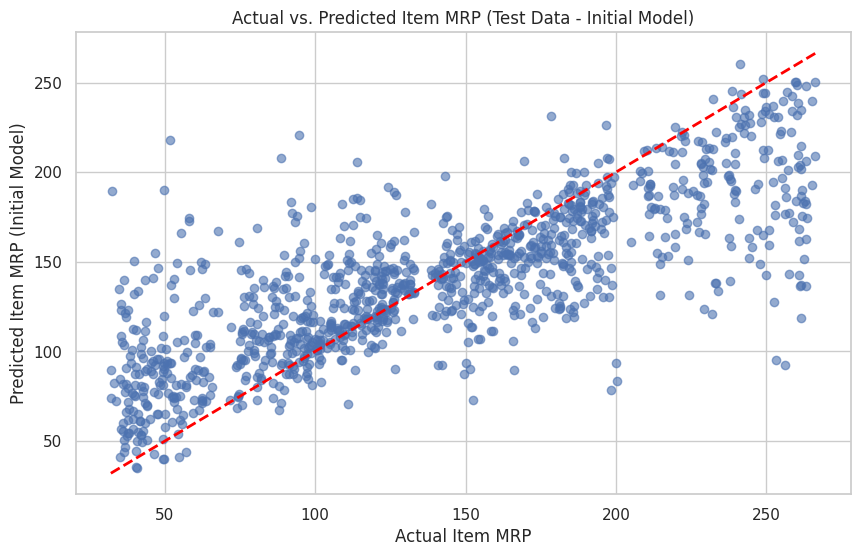

In [92]:
# Actual vs. Predicted Item MRP (Initial Model)
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, test_data_prediction, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Item MRP')
plt.ylabel('Predicted Item MRP (Initial Model)')
plt.title('Actual vs. Predicted Item MRP (Test Data - Initial Model)')
plt.grid(True)
plt.savefig('figures/consolidated_actual_vs_predicted_initial.png', transparent=True)
plt.show()

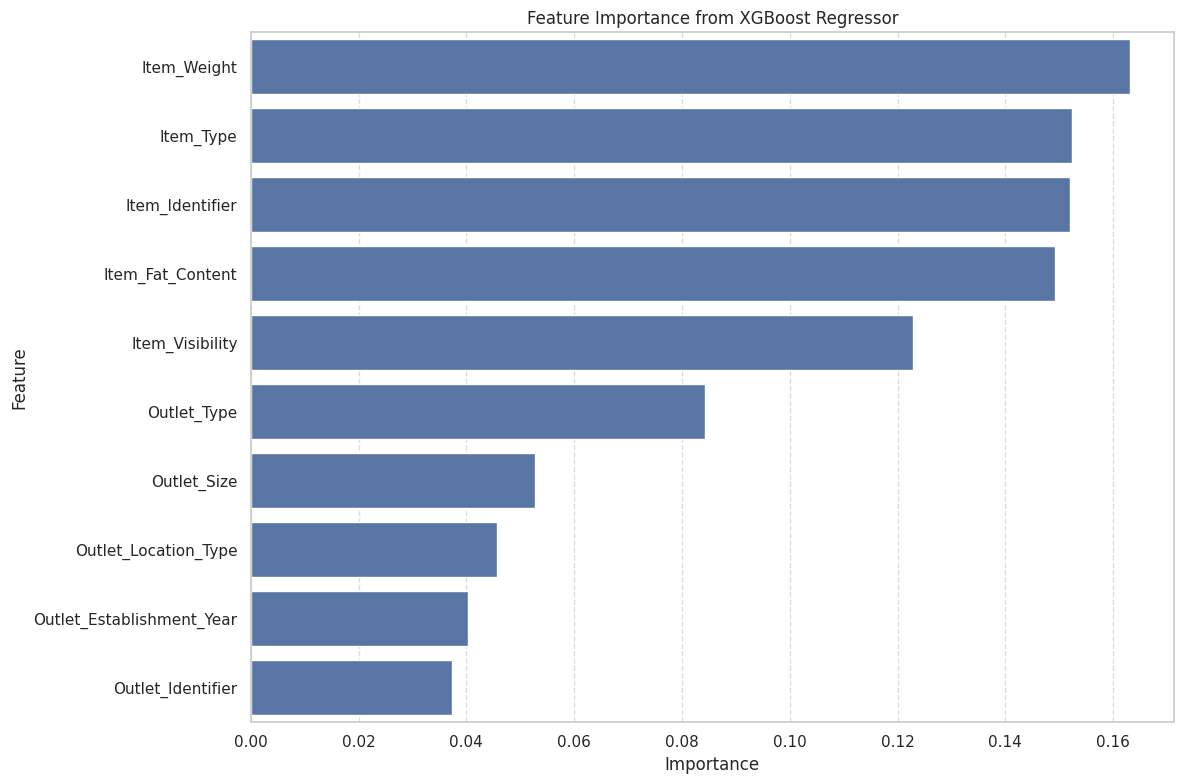

In [93]:
# Feature Importance from XGBoost Regressor
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importance from XGBoost Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('figures/consolidated_feature_importance.png', transparent=True)
plt.show()

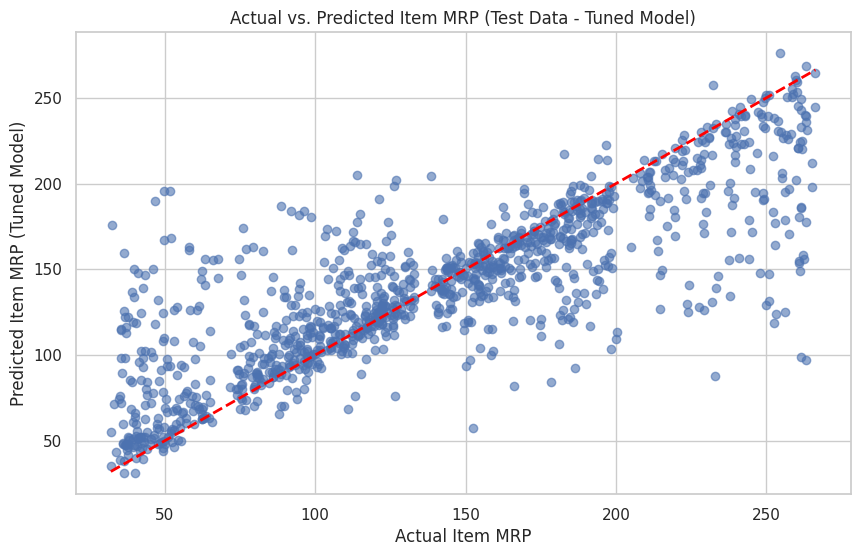

In [94]:
# Actual vs. Predicted Item MRP (Tuned Model)
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, tuned_test_data_prediction, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Item MRP')
plt.ylabel('Predicted Item MRP (Tuned Model)')
plt.title('Actual vs. Predicted Item MRP (Test Data - Tuned Model)')
plt.grid(True)
plt.savefig('figures/consolidated_actual_vs_predicted_tuned.png', transparent=True)
plt.show()

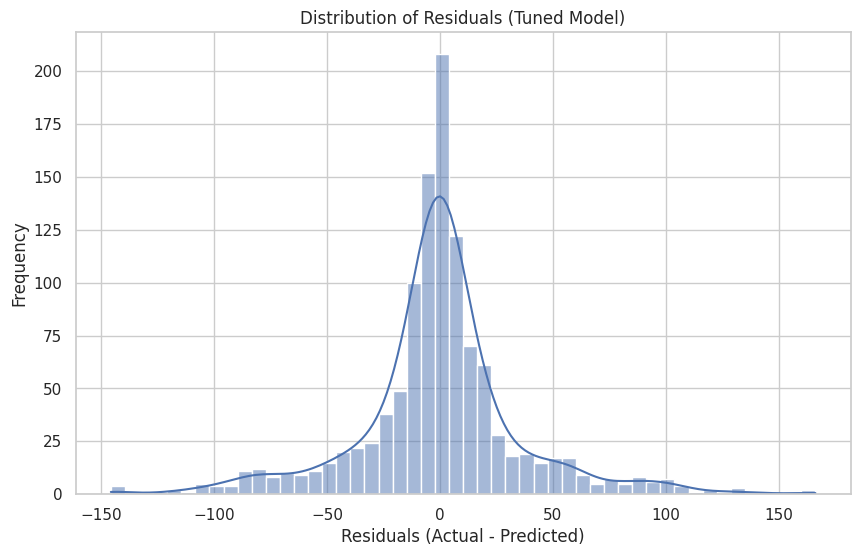

In [101]:
# Distribution of Residuals (Tuned Model)
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Distribution of Residuals (Tuned Model)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('figures/consolidated_residuals_distribution.png', transparent=True)
plt.show()

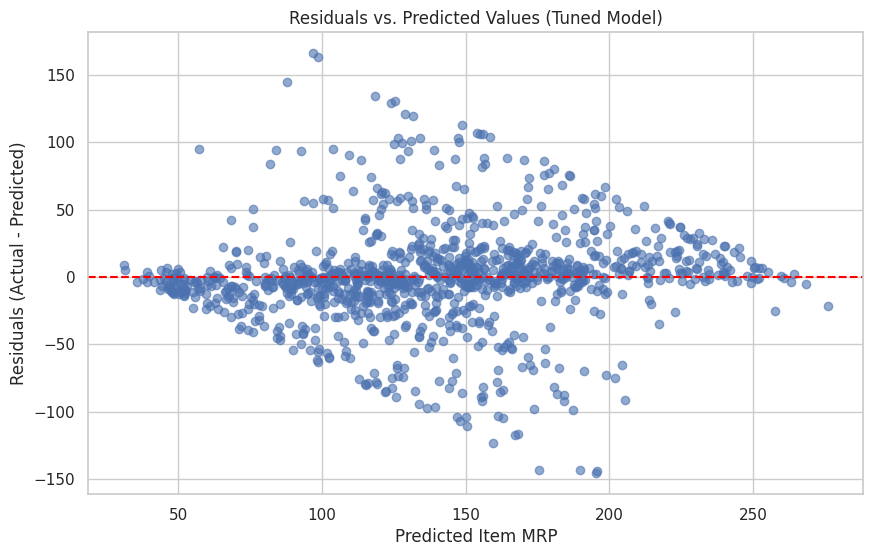

In [102]:
# Residuals vs. Predicted Values (Tuned Model)
plt.figure(figsize=(10, 6))
plt.scatter(tuned_test_data_prediction, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Tuned Model)')
plt.xlabel('Predicted Item MRP')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.savefig('figures/consolidated_residuals_vs_predicted.png', transparent=True)
plt.show()